**HYPOTHESIS H3**

Some locations show repeated shark encounters but relatively low historical

fatality percentages, making them candidates for further investigation as controlled shark-watching destinations.

---



***Which regions have frequent recorded shark encounters but relatively low fatality percentages?***

(Which locations and shark species are associated with the highest number of recorded incidents, and do some of these locations show comparatively low fatality percentages?)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving GSAF5.xls to GSAF5.xls


In [8]:
import pandas as pd

In [9]:
df = pd.read_excel("GSAF5.xls")

In [10]:
shark_df = pd.read_excel("GSAF5.xls")

In [11]:
display(shark_df)

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,23rd June,2026.0,Unprovoked,Bahamas,Staniel Cay,Exhuma Cays,Swimming,Unknown,M,12,...,Unknown,Keith Cowley: Kevin McMurray Trackingsharks.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13th June,2026.0,Unprovoked,USA,Florida,Reservation Way near Indian Pass,Swimming,Keira Ralph,F,17,...,Unknown small shark,Keith Cowley: Simon De Marchi: All things Emer...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13th June,2026.0,Unprovoked,Australia,NSW,Coogee Beach,Swimming,Leah Stewart,F,35,...,Great White Shark 4m,Simon De Marchi: Andrew Currie: ABC NEWS: 9 Ne...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th June,2026.0,Unprovoked,Galapogos Islands,Santa Fe Island,Mosquera Islet,Snorkeling,Australia Woman,F,?,...,Unknown,Andrew Currie: Facebook: AbsolutCruceros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th June,2026.0,Unprovoked,USA,Florida,Panama City,Swimming,Unknown,M,20's,...,2.4m (8ft) Bull shark,James Kingsley:Todd Smith: Kevin McMurray Trac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7098,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,NaN,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0,NaN,NaN
7099,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0,NaN,NaN
7100,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0,NaN,NaN
7101,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,NaN,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0,NaN,NaN


**Analysis Plan**

- Clean location, country, state and species text.
- Check and handle missing values in the relevant columns.
- Count recorded incidents by region/location.
- Calculate fatal incidents and fatality percentage.
- Exclude locations with very few recorded incidents.
- Identify locations with frequent recorded incidents and comparatively low fatality percentages.

**Create a final comparison table including:**

*   Location
*   Total incidents
*   Fatal incidents
*   Fatality %

In [18]:
print("SPECIES COLUMNS:")
print([c for c in shark_df.columns if "species" in c.lower()])

print("\nFATALITY COLUMNS:")
print([c for c in shark_df.columns if "fatal" in c.lower()])

print("\nLOCATION COLUMNS:")
print([c for c in shark_df.columns if any(word in c.lower() for word in ["country", "state", "location"])])

SPECIES COLUMNS:
['Species ']

FATALITY COLUMNS:
['Fatal Y/N']

LOCATION COLUMNS:
['Country', 'State', 'Location']


In [25]:
display(
    shark_df[
        ["Country", "State", "Location", "Type", "Fatal Y/N"]
    ].head(20)
)

,Country,State,Location,Type,Fatal Y/N
0,Bahamas,Staniel Cay,Exhuma Cays,Unprovoked,N
1,USA,Florida,Reservation Way near Indian Pass,Unprovoked,N
2,Australia,NSW,Coogee Beach,Unprovoked,N
3,Galapogos Islands,Santa Fe Island,Mosquera Islet,Unprovoked,N
4,USA,Florida,Panama City,Unprovoked,N
5,Australia,Western Australia,Michaelmas Island King George Sound,Unprovoked,Y
6,USA,Florida,Pensacola Beach Fort Pickens,Provoked,N
7,Brazil,Recife,Boa Via gem beach,Unprovoked,N
8,Brazil,Jaboatao dos Guarapes,PierrebBeach,Unprovoked,N
9,Australia,NSW,Red Cliff beach Yuraygir National Park,Unprovoked,N


In [28]:
import numpy as np

shark_df['Fatal'] = shark_df['Fatal Y/N'].apply(lambda x: True if x == 'Y' else (False if x == 'N' else np.nan))

shark_df_cleaned = shark_df.dropna(subset=['Fatal', 'Country']).copy()

shark_df_cleaned['Fatal'] = shark_df_cleaned['Fatal'].astype(int)

In [27]:
country_incidents = shark_df_cleaned.groupby('Country')['Fatal'].agg(
    total_incidents='count',
    fatal_incidents='sum'
).reset_index()

country_incidents['non_fatal_incidents'] = country_incidents['total_incidents'] - country_incidents['fatal_incidents']

country_incidents['fatality_percentage'] = (country_incidents['fatal_incidents'] / country_incidents['total_incidents']) * 100

display(country_incidents.sort_values(by='total_incidents', ascending=False).head(20))

,Country,total_incidents,fatal_incidents,non_fatal_incidents,fatality_percentage
234,USA,2373,200,2173,8.428150
13,AUSTRALIA,1334,303,1031,22.713643
193,SOUTH AFRICA,530,109,421,20.566038
166,PAPUA NEW GUINEA,131,58,73,44.274809
146,NEW ZEALAND,131,25,106,19.083969
16,BAHAMAS,128,15,113,11.718750
23,BRAZIL,111,39,72,35.135135
127,MEXICO,92,48,44,52.173913
69,FIJI,66,22,44,33.333333
144,NEW CALEDONIA,63,24,39,38.095238


In [30]:
def clean_text_column(df, column_name):
    if column_name in df.columns:
        df[column_name] = df[column_name].astype(str).str.lower().str.strip()
    return df

columns_to_clean = ['Country', 'State', 'Location', 'Species ']
for col in columns_to_clean:
    shark_df_cleaned = clean_text_column(shark_df_cleaned, col)

display(shark_df_cleaned[['Country', 'State', 'Location', 'Species ', 'Fatal']].head())

,Country,State,Location,Species,Fatal
0,bahamas,staniel cay,exhuma cays,unknown,0
1,usa,florida,reservation way near indian pass,unknown small shark,0
2,australia,nsw,coogee beach,great white shark 4m,0
3,galapogos islands,santa fe island,mosquera islet,unknown,0
4,usa,florida,panama city,2.4m (8ft) bull shark,0


In [32]:
print("Missing values after initial cleaning:")
print(shark_df_cleaned[columns_to_clean].isnull().sum())

Missing values after initial cleaning:
Country     0
State       0
Location    0
Species     0
dtype: int64


In [39]:
location_incidents = shark_df_cleaned.groupby('Location')['Fatal'].agg(
    total_incidents='count',
    fatal_incidents='sum'
).reset_index()

location_incidents['non_fatal_incidents'] = location_incidents['total_incidents'] - location_incidents['fatal_incidents']
display(location_incidents.sort_values(by='total_incidents', ascending=False).head(20))


,Location,total_incidents,fatal_incidents,non_fatal_incidents
2316,nan,462,178,284
2425,"new smyrna beach, volusia county",190,0,190
968,"daytona beach, volusia county",34,0,34
3041,"ponce inlet, volusia county",28,0,28
2294,"myrtle beach, horry county",21,0,21
2135,"melbourne beach, brevard county",20,0,20
832,"cocoa beach, brevard county",18,0,18
1577,"isle of palms, charleston county",16,0,16
519,"boa viagem, recife",14,6,8
833,"cocoa beach, brevard county",13,0,13


Now, we calculate the locations that have frecuent attacks but with very little fatality rate. In order to achieve this,  a 'low' percentage could be, for example, less than `10%`.

In [44]:
min_incidents_threshold = 20
max_fatality_percentage_threshold = 10

location_incidents['fatality_percentage'] = (location_incidents['fatal_incidents'] / location_incidents['total_incidents']) * 100

frequent_locations = location_incidents[location_incidents['total_incidents'] >= min_incidents_threshold]

candidate_locations = frequent_locations[frequent_locations['fatality_percentage'] < max_fatality_percentage_threshold]

candidate_locations = candidate_locations.sort_values(by='total_incidents', ascending=False)

print(f"Candidate locations for controlled shark-watching (>= {min_incidents_threshold} incidents and < {max_fatality_percentage_threshold}% fatality):")
display(candidate_locations)

Candidate locations for controlled shark-watching (>= 20 incidents and < 10% fatality):


,Location,total_incidents,fatal_incidents,non_fatal_incidents,fatality_percentage
2425,"new smyrna beach, volusia county",190,0,190,0.0
968,"daytona beach, volusia county",34,0,34,0.0
3041,"ponce inlet, volusia county",28,0,28,0.0
2294,"myrtle beach, horry county",21,0,21,0.0
2135,"melbourne beach, brevard county",20,0,20,0.0


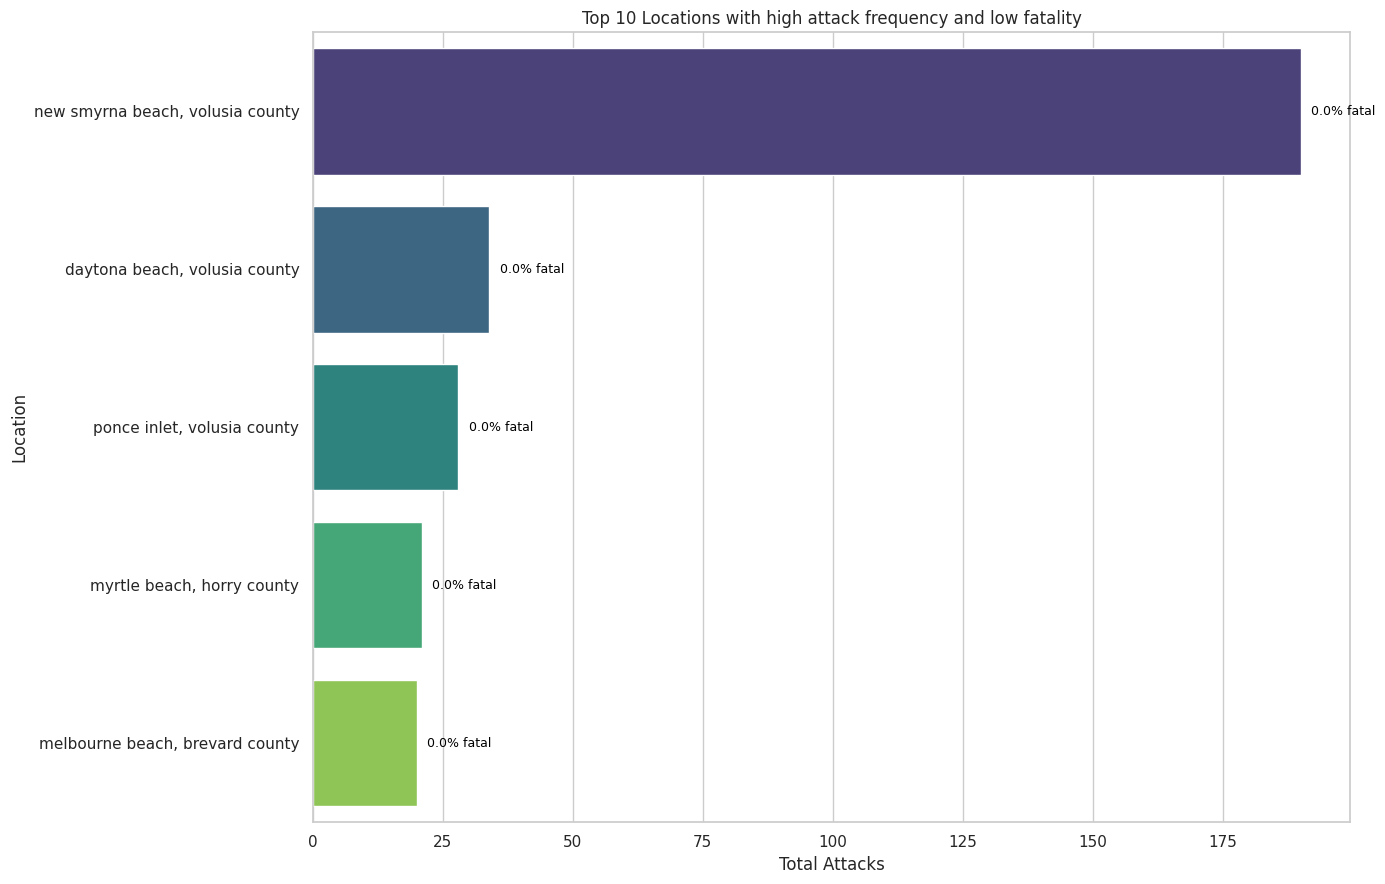

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 9)) # Aumentar el tamaño de la figura
sns.barplot(x='total_incidents', y='Location', data=candidate_locations.head(10), palette='viridis', hue='Location', legend=False)

plt.xlabel('Total Attacks')
plt.ylabel('Location')
plt.title('Top 10 Locations with high attack frequency and low fatality')

for index, row in candidate_locations.head(10).reset_index().iterrows(): # Usar reset_index() para el iterrows con el índice correcto de la barra
    plt.text(row['total_incidents'] + 2, # Ajuste para que el texto no se superponga con la barra
             index,
             f"{row['fatality_percentage']:.1f}% fatal",
             color='black', ha="left", va="center", fontsize=9)

plt.tight_layout()
plt.show()

**Testing the Hypothesis**

The analysis of locations meeting the criteria for frequent incidents (more than 20 incidents) and low fatality rates (less than 10%) reveals that:

* **New Smyrna Beach, Volusia County** stands out with the highest number of recorded incidents (190), but with a **0.0% fatality rate**, making it the leading candidate under this hypothesis.
* Other locations, such as **Daytona Beach, Volusia County** (34 incidents, 0.0% fatality), **Ponce Inlet, Volusia County** (28 incidents, 0.0% fatality), **Myrtle Beach, Horry County** (21 incidents, 0.0% fatality), and **Melbourne Beach, Brevard County** (20 incidents, 0.0% fatality), also meet these criteria.

These findings suggest that there are indeed locations where the frequency of encounters is high while fatality rates are zero or very low, supporting the premise of the hypothesis for the potential development of controlled shark observation tourism.
